In [52]:
import inspect
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from helper_functions import *

In [53]:
base_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy/Kimera_VIO_Output'
experiment_dir = 'Software_Timestamping _RTOS_IMU'

In [54]:
folders = next(os.walk(f'{base_dir}/{experiment_dir}'))[1]

In [55]:
folders

['IMU_Error_0.75ms_4Hz_Frame',
 'IMU_Error_0.5ms_4Hz_Frame',
 'IMU_Error_0.001ms_4Hz_Frame',
 'IMU_Error_0.5ms_6Hz_Frame',
 'IMU_Error_1ms_4Hz_Frame',
 'IMU_Error_0.25ms_6Hz_Frame',
 'IMU_Error_1ms_6Hz_Frame',
 'IMU_Error_0.25ms_4Hz_Frame',
 'IMU_Error_0.001ms_6Hz_Frame',
 'IMU_Error_0.75ms_6Hz_Frame']

In [56]:
dfs = []
execution_index = 1

for index, execution_folder_name in enumerate(folders):
    df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_vio.csv')
    df['Execution'] = execution_folder_name
    df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
    dfs.append(df)

In [57]:
gt_df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_gt.csv')
gt_df['Execution'] = 'GT'
gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
dfs.append(gt_df)

In [58]:
gt_df.shape

(22401, 18)

In [59]:
all_executions = pd.concat(dfs)

In [60]:
all_executions.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 27803 entries, 0 to 22400
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  27803 non-null  int64  
 1   x          27803 non-null  float64
 2   y          27803 non-null  float64
 3   z          27803 non-null  float64
 4   qw         27803 non-null  float64
 5   qx         27803 non-null  float64
 6   qy         27803 non-null  float64
 7   qz         27803 non-null  float64
 8   vx         27803 non-null  float64
 9   vy         27803 non-null  float64
 10  vz         27803 non-null  float64
 11  bgx        27803 non-null  float64
 12  bgy        27803 non-null  float64
 13  bgz        27803 non-null  float64
 14  bax        27803 non-null  float64
 15  bay        27803 non-null  float64
 16  baz        27803 non-null  float64
 17  Execution  27803 non-null  object 
dtypes: float64(16), int64(1), object(1)
memory usage: 4.0+ MB


In [61]:
sns.set_theme(rc={'figure.figsize':(12,6)})

In [62]:
folders

['IMU_Error_0.75ms_4Hz_Frame',
 'IMU_Error_0.5ms_4Hz_Frame',
 'IMU_Error_0.001ms_4Hz_Frame',
 'IMU_Error_0.5ms_6Hz_Frame',
 'IMU_Error_1ms_4Hz_Frame',
 'IMU_Error_0.25ms_6Hz_Frame',
 'IMU_Error_1ms_6Hz_Frame',
 'IMU_Error_0.25ms_4Hz_Frame',
 'IMU_Error_0.001ms_6Hz_Frame',
 'IMU_Error_0.75ms_6Hz_Frame']

In [63]:
hue_order = [folders[2], folders[-2], folders[5], folders[7], folders[2], folders[3], folders[0], folders[-1], folders[4], folders[6]]

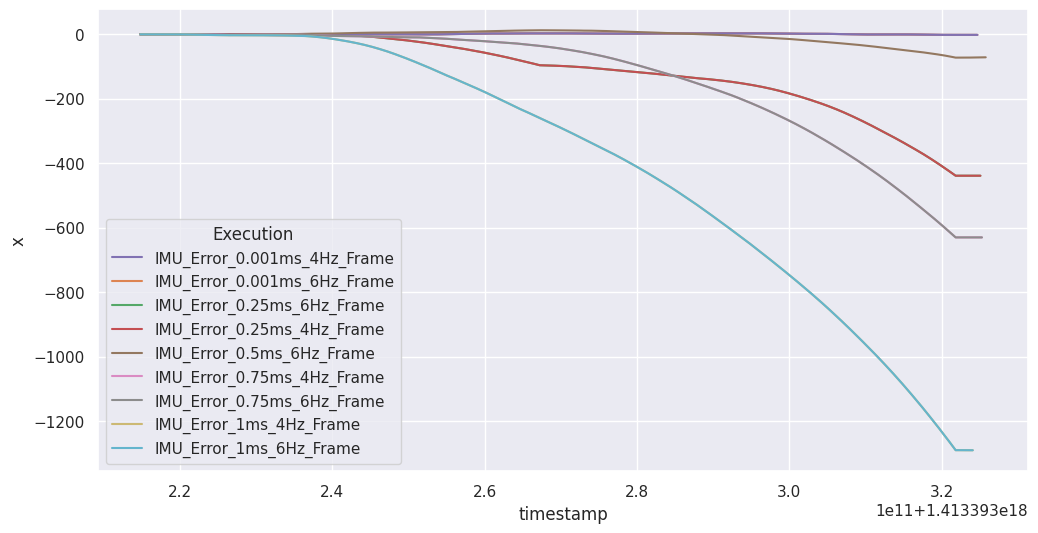

In [64]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='x', hue='Execution', hue_order = hue_order)
# ax.set(ylim=(-4, 4))

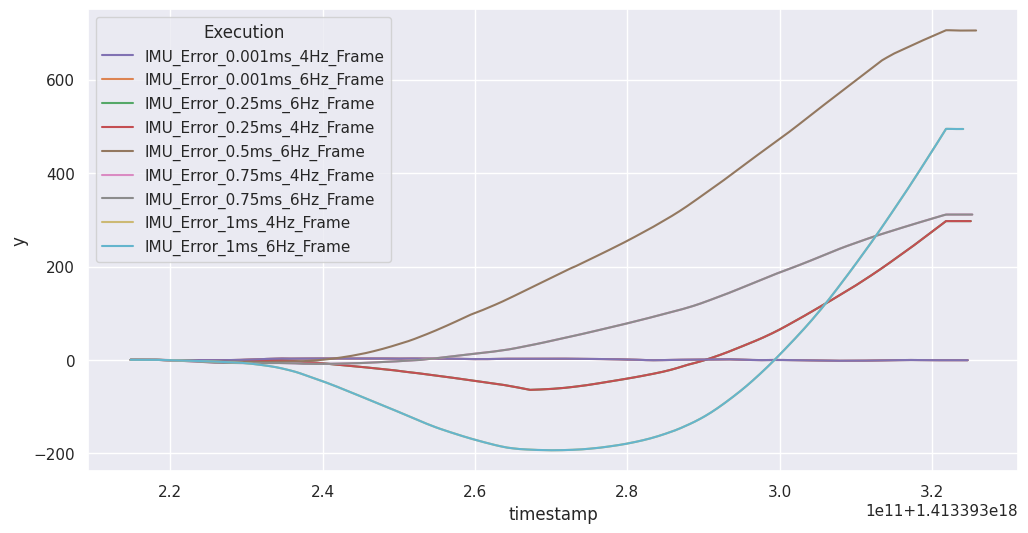

In [65]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='y', hue='Execution', hue_order = hue_order)
# ax.set(ylim=(-4, 4))

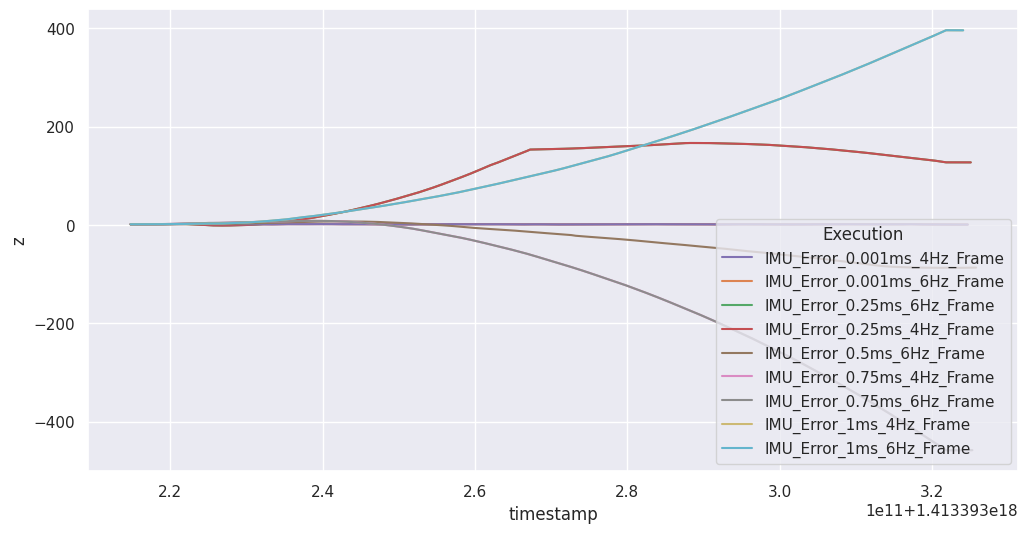

In [66]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='z', hue='Execution', hue_order = hue_order)

In [67]:
np.set_printoptions(precision=20)
pd.set_option('display.float_format', '{:.20f}'.format)

In [68]:
sns.set_theme(rc={'figure.figsize':(12,10)})

values = {}
for df in dfs:
    error_df = generate_error_gt_vio_pose(gt_df, df, DEBUG=False, SHOW_GRAPHS=False)
    values[df.iloc[0]['Execution']] = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
                'gt_y':error_df.iloc[-1]['gt_pos'][1],
                'gt_z':error_df.iloc[-1]['gt_pos'][2],
                'vio_x': error_df.iloc[-1]['vio_pos'][0],
                'vio_y': error_df.iloc[-1]['vio_pos'][1],
                'vio_z': error_df.iloc[-1]['vio_pos'][2],
                'distance': error_df['distance'],
                'error': error_df['error']
                }

# df_comparison = pd.DataFrame(values).T
# df_comparison.reset_index(inplace=True)

# df_comparison_x_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_x', 'vio_x'])
# df_comparison_y_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_y', 'vio_y'])
# df_comparison_z_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_z', 'vio_z'])

539
541
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []
541
541
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []
539
541
539
541
541
539
22401
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []


In [69]:
values.keys()

dict_keys(['IMU_Error_0.75ms_4Hz_Frame', 'IMU_Error_0.5ms_4Hz_Frame', 'IMU_Error_0.001ms_4Hz_Frame', 'IMU_Error_0.5ms_6Hz_Frame', 'IMU_Error_1ms_4Hz_Frame', 'IMU_Error_0.25ms_6Hz_Frame', 'IMU_Error_1ms_6Hz_Frame', 'IMU_Error_0.25ms_4Hz_Frame', 'IMU_Error_0.001ms_6Hz_Frame', 'IMU_Error_0.75ms_6Hz_Frame', 'GT'])

In [70]:
error_distance_dfs = []

for i in values.keys():
    err_df = pd.DataFrame(data={'Distance (m)': values[i]['distance'], 'Error (m)':values[i]['error'], 'Execution':i})
    error_distance_dfs.append(err_df)

error_distance_dfs = pd.concat(error_distance_dfs)

In [71]:
res = []

for exec_no, data in error_distance_dfs.groupby('Execution'):
    print(exec_no)
    res.append(data.iloc[-1])

GT
IMU_Error_0.001ms_4Hz_Frame
IMU_Error_0.001ms_6Hz_Frame
IMU_Error_0.25ms_4Hz_Frame
IMU_Error_0.25ms_6Hz_Frame
IMU_Error_0.5ms_4Hz_Frame
IMU_Error_0.5ms_6Hz_Frame
IMU_Error_0.75ms_4Hz_Frame
IMU_Error_0.75ms_6Hz_Frame
IMU_Error_1ms_4Hz_Frame
IMU_Error_1ms_6Hz_Frame


In [72]:
res = pd.DataFrame(res)

In [73]:
error_distance_dfs['Execution'].unique()

array(['IMU_Error_0.75ms_4Hz_Frame', 'IMU_Error_0.5ms_4Hz_Frame',
       'IMU_Error_0.001ms_4Hz_Frame', 'IMU_Error_0.5ms_6Hz_Frame',
       'IMU_Error_1ms_4Hz_Frame', 'IMU_Error_0.25ms_6Hz_Frame',
       'IMU_Error_1ms_6Hz_Frame', 'IMU_Error_0.25ms_4Hz_Frame',
       'IMU_Error_0.001ms_6Hz_Frame', 'IMU_Error_0.75ms_6Hz_Frame', 'GT'],
      dtype=object)

Text(0.5, 1.0, 'Error as Distance Increases - Baseline Experiments')

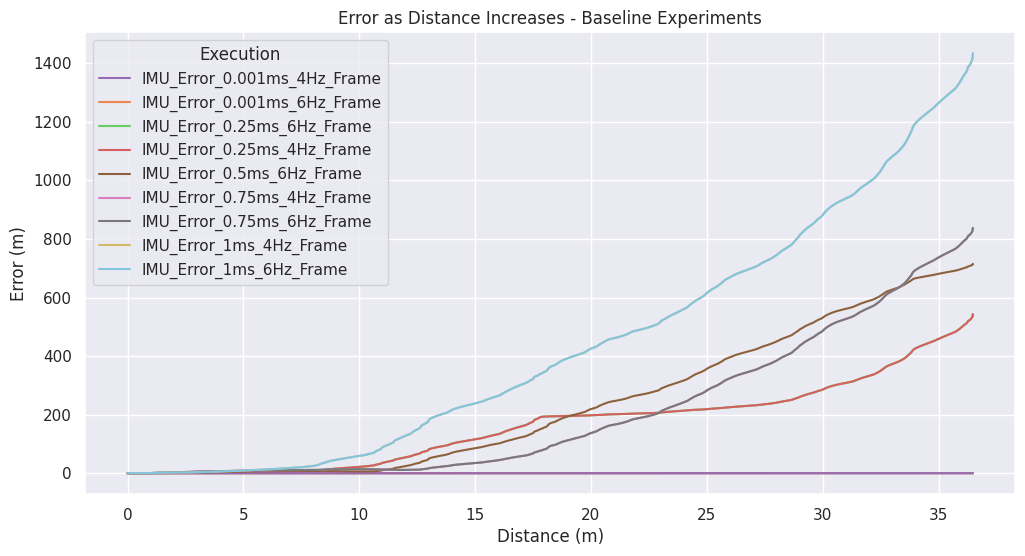

In [74]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases - Baseline Experiments'

g = sns.lineplot(data = error_distance_dfs, x='Distance (m)', y = 'Error (m)', hue='Execution', legend='full', palette='muted', hue_order = hue_order)
g.set_title(title)